# Historical flood exposure

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
from tqdm.auto import tqdm

from src.datasources import codab, floodscan, worldpop
from src.utils import blob

In [3]:
pop = worldpop.load_worldpop_from_blob()

In [4]:
pop = pop.rename({"x": "lon", "y": "lat"})

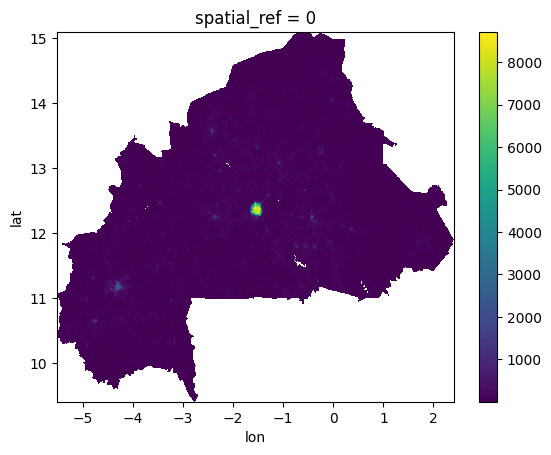

In [5]:
pop.plot()

In [6]:
int(pop.sum())

20903278

In [104]:
dicts = []
for pcode, row in tqdm(adm.set_index("ADM2_PCODE").iterrows(), total=len(adm)):
    dicts.append(
        {
            "total_pop": int(pop.rio.clip([row.geometry]).sum()),
            "ADM2_PCODE": pcode,
        }
    )

  0%|          | 0/45 [00:00<?, ?it/s]

In [105]:
df_pop = pd.DataFrame(dicts)

In [106]:
df_pop

,total_pop,ADM2_PCODE
0,329847,BF5103
1,304850,BF5003
2,158525,BF5502
3,243927,BF5101
4,475460,BF5603
5,670640,BF5403
6,3872172,BF1300
7,1474643,BF5301
8,279525,BF5503
9,382859,BF4604


In [3]:
codab.download_codab_to_blob()

In [3]:
adm = codab.load_codab_from_blob()

AttributeError: module 'fiona' has no attribute 'path'

<Axes: >

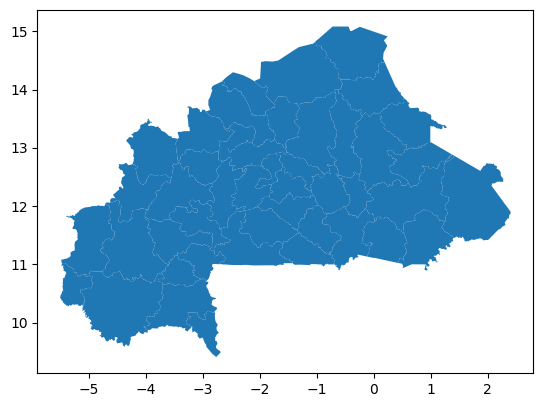

In [4]:
adm.plot()

In [10]:
df = floodscan.load_tabular_flood_exposure()

In [11]:
df

,date,total_exposed,ADM2_PCODE
0,1998-01-12,0.0,BF5103
1,1998-01-13,0.0,BF5103
2,1998-01-14,0.0,BF5103
3,1998-01-15,0.0,BF5103
4,1998-01-16,0.0,BF5103
...,...,...,...
426820,2023-12-27,0.0,BF4901
426821,2023-12-28,0.0,BF4901
426822,2023-12-29,0.0,BF4901
426823,2023-12-30,0.0,BF4901


In [9]:
da = floodscan.open_historical_floodscan()

/Users/tdowning/.pyenv/versions/ds-aa-bfa-flooding/lib/python3.11/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/Users/tdowning/.pyenv/versions/ds-aa-bfa-flooding/lib/python3.11/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/Users/tdowning/.pyenv/versions/ds-aa-bfa-flooding/lib/python3.11/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [10]:
da

<xarray.DataArray 'SFED_AREA' (lat: 1080, lon: 1080, time: 9485)> Size: 44GB
dask.array<open_dataset-SFED_AREA, shape=(1080, 1080, 9485), dtype=float32, chunksize=(100, 100, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 76kB 1998-01-12 1998-01-13 ... 2023-12-31
  * lat      (lat) float64 9kB 39.96 39.87 39.79 39.71 ... -49.79 -49.88 -49.96
  * lon      (lon) float64 9kB -29.96 -29.88 -29.79 -29.71 ... 59.79 59.88 59.96
    crs      int64 8B 0
Attributes:
    grid_mapping:  crs
    description:   0-1 fraction of unmasked area with SFED flooding aggregate...
    valid_range:   [0. 1.]
    units:         1

In [11]:
da_clip = da.rio.clip(adm.geometry, all_touched=True)

In [12]:
da_clip_filtered = da_clip.where(da_clip >= 0.05)

In [13]:
da_year = da_clip_filtered.groupby("time.year").max()

/Users/tdowning/.pyenv/versions/ds-aa-bfa-flooding/lib/python3.11/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


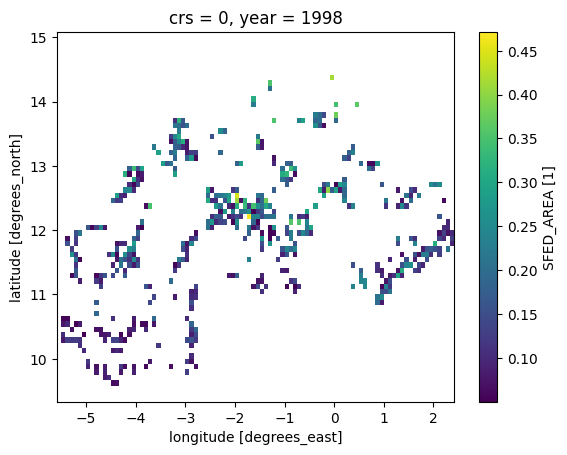

In [14]:
da_year.isel(year=0).plot()

In [15]:
exposure = da_year.interp_like(pop, method="nearest") * pop

In [16]:
da_year

<xarray.DataArray 'SFED_AREA' (lat: 69, lon: 96, year: 26)> Size: 689kB
dask.array<transpose, shape=(69, 96, 26), dtype=float32, chunksize=(68, 89, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 552B 15.04 14.96 14.87 14.79 ... 9.542 9.458 9.375
  * lon      (lon) float64 768B -5.542 -5.458 -5.375 ... 2.208 2.292 2.375
    crs      int64 8B 0
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
Attributes:
    grid_mapping:  crs
    description:   0-1 fraction of unmasked area with SFED flooding aggregate...
    valid_range:   [0. 1.]
    units:         1

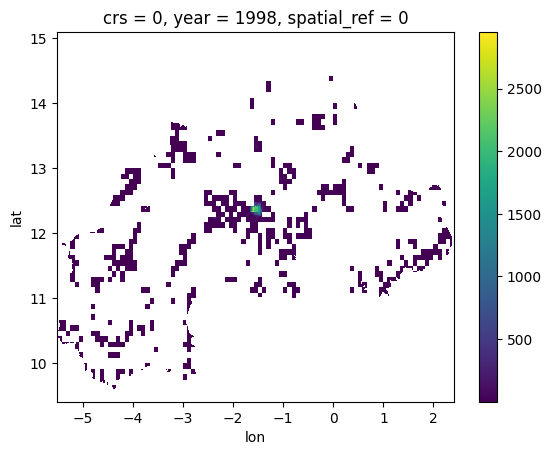

In [17]:
exposure.isel(year=0).plot()

In [18]:
exposure = exposure.rio.set_spatial_dims(y_dim="lat", x_dim="lon")

In [19]:
exposure = exposure.persist()

In [20]:
exposure = exposure.rio.set_spatial_dims(y_dim="lat", x_dim="lon")

In [21]:
exposure

<xarray.DataArray (lat: 682, lon: 951, year: 26)> Size: 67MB
dask.array<mul, shape=(682, 951, 26), dtype=float32, chunksize=(682, 951, 1), chunktype=numpy.ndarray>
Coordinates:
    crs          int64 8B 0
  * year         (year) int64 208B 1998 1999 2000 2001 ... 2020 2021 2022 2023
  * lat          (lat) float64 5kB 15.09 15.08 15.07 15.06 ... 9.429 9.42 9.412
  * lon          (lon) float64 8kB -5.514 -5.505 -5.497 ... 2.386 2.395 2.403
    spatial_ref  int64 8B 0

In [91]:
dfs = []
for pcode, row in tqdm(adm.set_index("ADM2_PCODE").iterrows(), total=len(adm)):
    da_adm = exposure.rio.clip([row.geometry])
    df_in = (
        da_adm.sum(dim=["lat", "lon"])
        .to_dataframe("max_exposure")["max_exposure"]
        .astype(int)
        .reset_index()
    )
    df_in["ADM2_PCODE"] = pcode
    dfs.append(df_in)

  0%|          | 0/45 [00:00<?, ?it/s]

In [92]:
df_year = pd.concat(dfs, ignore_index=True)

In [93]:
df_year

,year,max_exposure,ADM2_PCODE
0,1998,13660,BF5103
1,1999,31756,BF5103
2,2000,1772,BF5103
3,2001,22985,BF5103
4,2002,24851,BF5103
...,...,...,...
1165,2019,0,BF4901
1166,2020,3534,BF4901
1167,2021,0,BF4901
1168,2022,4530,BF4901


In [94]:
blob_name = (
    f"{blob.PROJECT_PREFIX}/processed/bfa_yearly_max_flood_exposure.parquet"
)
blob.upload_parquet_to_blob(blob_name, df_year)

In [107]:
df_year = df_year.merge(df_pop)

In [109]:
df_year["max_frac_exposure"] = df_year["max_exposure"] / df_year["total_pop"]

In [118]:
df_year_mean = (
    df_year.groupby("ADM2_PCODE")
    .mean()[["max_exposure", "max_frac_exposure"]]
    .reset_index()
)

In [167]:
def thousands_formatter(x, pos):
    return "{:,.0f}".format(x)

Text(0.5, 1.0, 'Average population exposed to flooding each year\nby province')

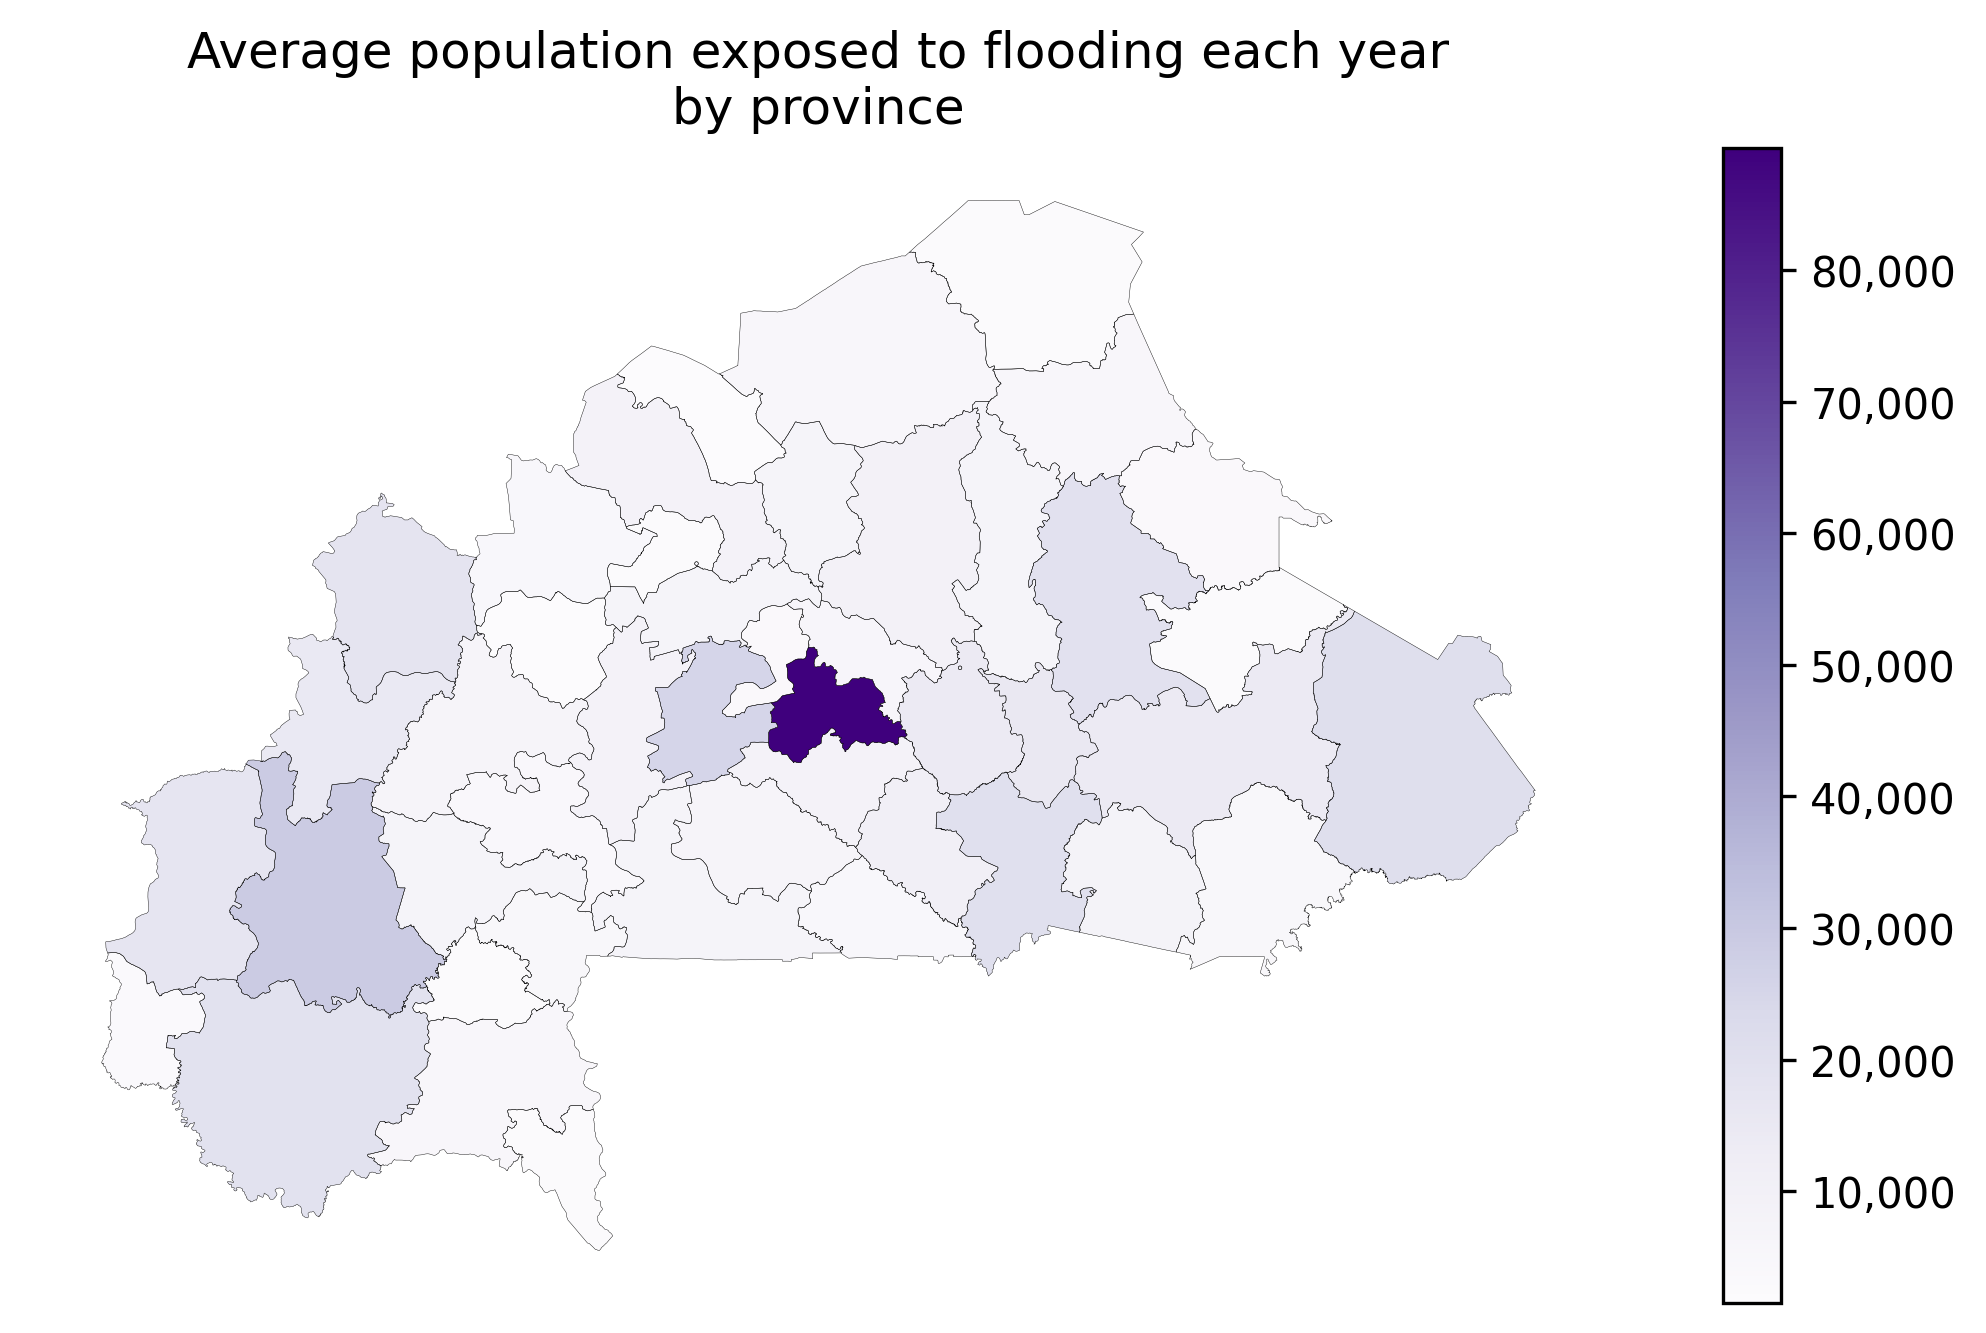

In [169]:
fig, ax = plt.subplots(dpi=300, figsize=(10, 5))
adm.merge(df_year_mean).plot(
    column="max_exposure", legend=True, ax=ax, cmap="Purples"
)
adm.boundary.plot(linewidth=0.1, color="k", ax=ax)
cbar = ax.get_figure().get_axes()[1]
cbar.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.axis("off")
ax.set_title("Average population exposed to flooding each year\nby province")

In [157]:
df_plot = df_year_mean.merge(adm[["ADM2_PCODE", "ADM2_FR", "ADM1_FR"]])[
    ["ADM1_FR", "ADM2_FR", "max_exposure", "max_frac_exposure"]
]
df_plot["max_exposure"] = df_plot["max_exposure"].astype(int)
df_plot.sort_values("max_exposure", ascending=False).iloc[:20].rename(
    columns={
        "max_exposure": "Avg. pop. exposed",
        "max_frac_exposure": "Avg. frac. pop. exp.",
        "ADM1_FR": "Région",
        "ADM2_FR": "Province",
    }
).style.background_gradient(
    cmap="Purples",
).format(
    "{:,.0f}", subset=["Avg. pop. exposed"]
).format(
    "{:.2f}", subset=["Avg. frac. pop. exp."]
)

,Région,Province,Avg. pop. exposed,Avg. frac. pop. exp.
0,Centre,Kadiogo,"89,274",0.02
27,Hauts-Bassins,Houet,"29,197",0.02
15,Centre-Ouest,Boulkiemdé,"25,283",0.04
26,Est,Tapoa,"20,892",0.04
9,Centre-Est,Boulgou,"20,250",0.03
22,Est,Gnagna,"19,647",0.03
7,Cascades,Comoé,"19,011",0.02
3,Boucle du Mouhoun,Kossi,"17,888",0.05
28,Hauts-Bassins,Kénédougou,"17,125",0.04
11,Centre-Est,Kourittenga,"15,322",0.03


Text(0.5, 1.0, 'Average fraction of population exposed to flooding each year\nby province')

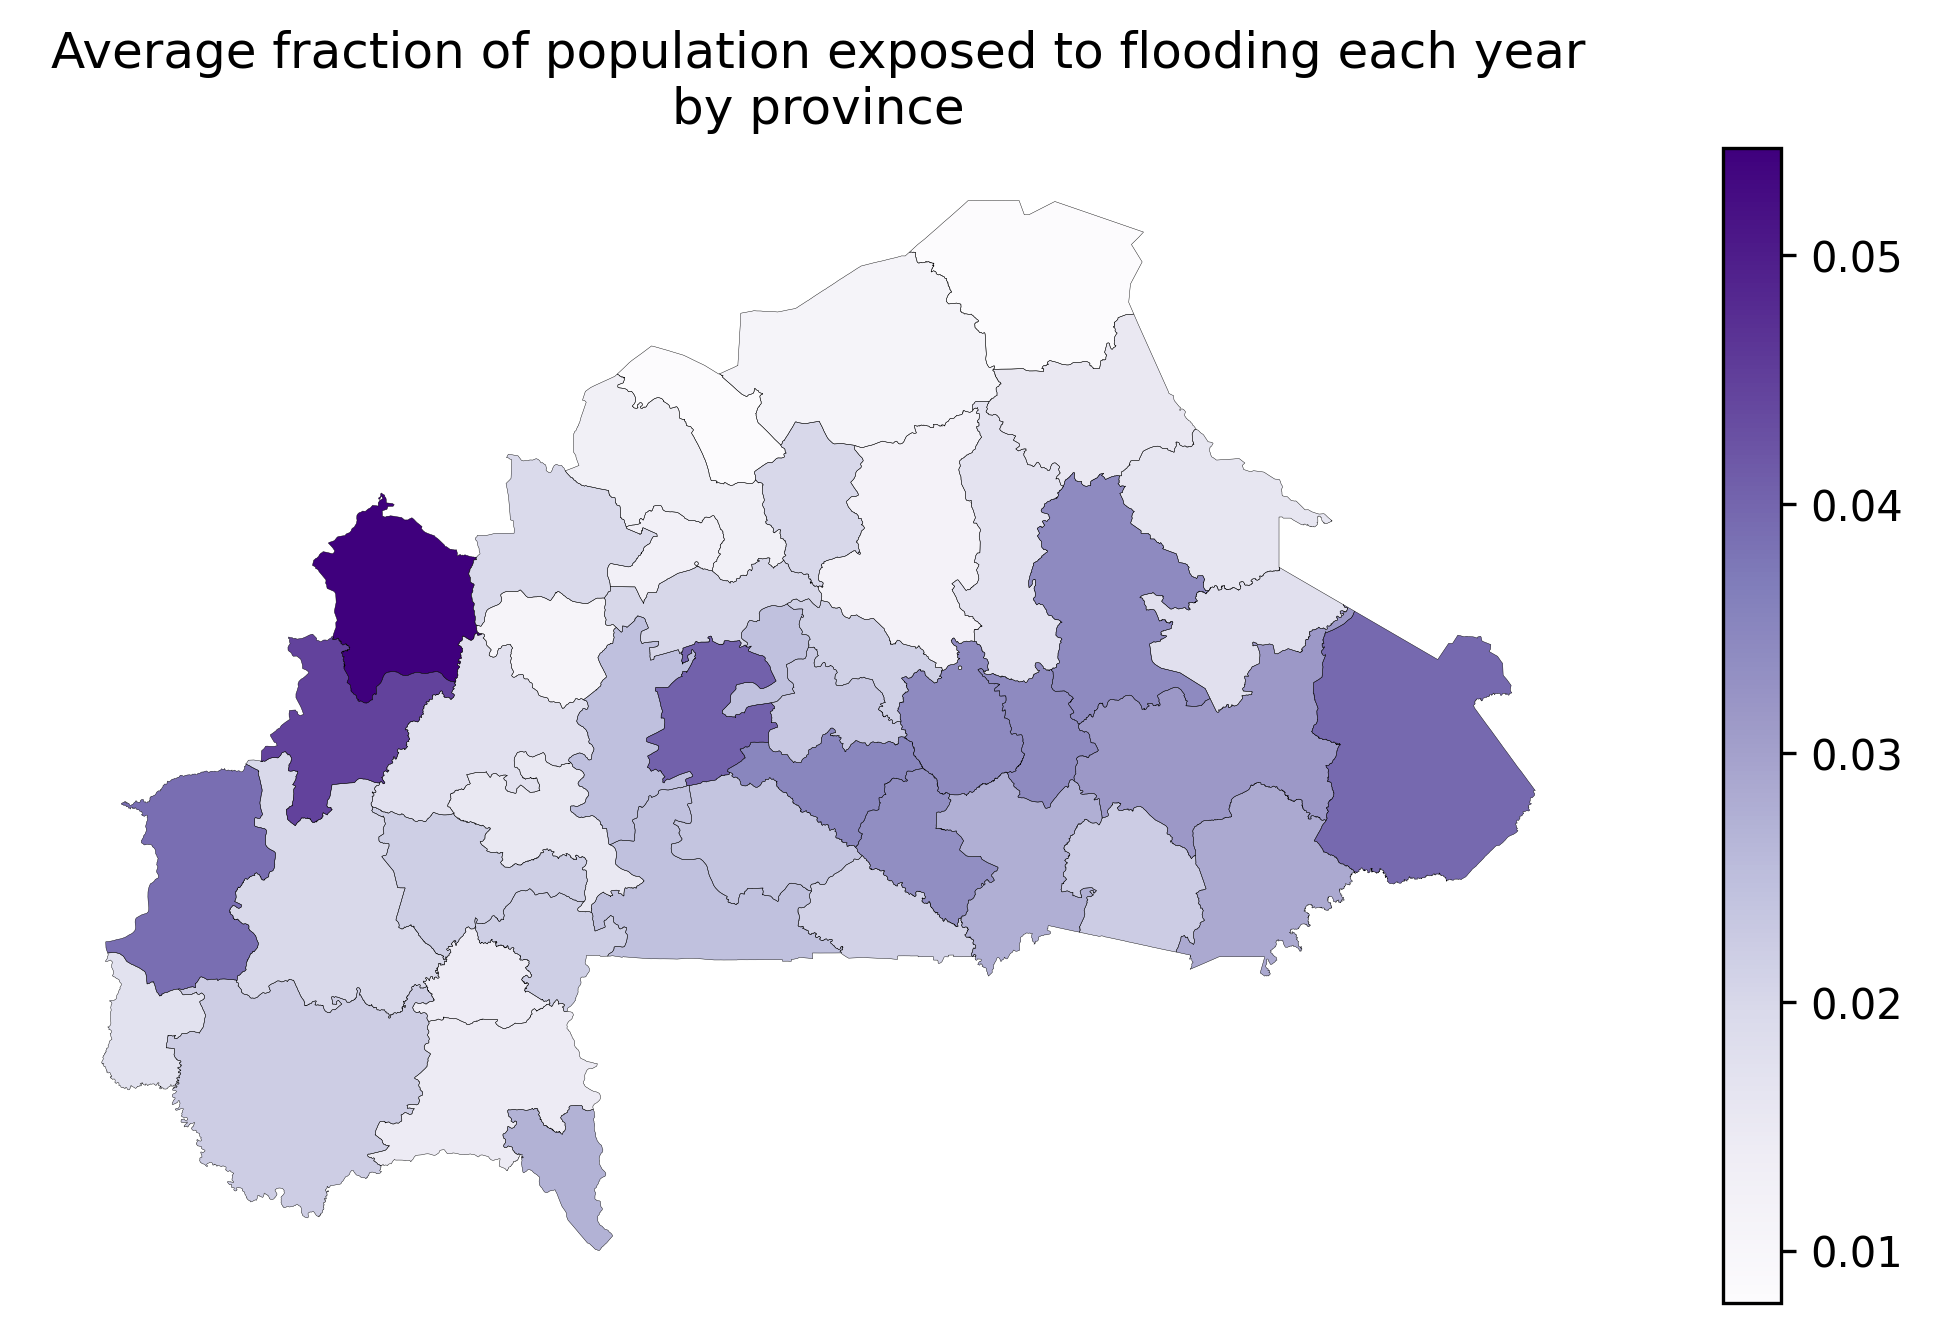

In [179]:
fig, ax = plt.subplots(dpi=300, figsize=(10, 5))
adm.merge(df_year_mean).plot(
    column="max_frac_exposure", legend=True, ax=ax, cmap="Purples"
)
ax.axis("off")
adm.boundary.plot(linewidth=0.1, color="k", ax=ax)
cbar = ax.get_figure().get_axes()[1]
# cbar.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.set_title(
    "Average fraction of population exposed to flooding each year\nby province"
)

In [158]:
df_plot.sort_values("max_frac_exposure", ascending=False).iloc[:20].rename(
    columns={
        "max_exposure": "Avg. pop. exposed",
        "max_frac_exposure": "Avg. frac. pop. exp.",
        "ADM1_FR": "Région",
        "ADM2_FR": "Province",
    }
).style.background_gradient(
    cmap="Purples",
).format(
    "{:,.0f}", subset=["Avg. pop. exposed"]
).format(
    "{:.2f}", subset=["Avg. frac. pop. exp."]
)

,Région,Province,Avg. pop. exposed,Avg. frac. pop. exp.
3,Boucle du Mouhoun,Kossi,"17,888",0.05
2,Boucle du Mouhoun,Banwa,"15,107",0.04
15,Centre-Ouest,Boulkiemdé,"25,283",0.04
26,Est,Tapoa,"20,892",0.04
28,Hauts-Bassins,Kénédougou,"17,125",0.04
19,Centre-Sud,Bazèga,"8,573",0.04
22,Est,Gnagna,"19,647",0.03
34,Plateau-Central,Ganzourgou,"14,296",0.03
11,Centre-Est,Kourittenga,"15,322",0.03
21,Centre-Sud,Zoundwéogo,"11,096",0.03


In [27]:
exposure_mean = exposure.mean(dim="year")

In [28]:
exposure_mean

<xarray.DataArray (lat: 682, lon: 951)> Size: 3MB
dask.array<mean_agg-aggregate, shape=(682, 951), dtype=float32, chunksize=(682, 951), chunktype=numpy.ndarray>
Coordinates:
    crs          int64 8B 0
  * lat          (lat) float64 5kB 15.09 15.08 15.07 15.06 ... 9.429 9.42 9.412
  * lon          (lon) float64 8kB -5.514 -5.505 -5.497 ... 2.386 2.395 2.403
    spatial_ref  int64 8B 0

In [52]:
da_year

<xarray.DataArray 'SFED_AREA' (lat: 69, lon: 96, year: 26)> Size: 689kB
dask.array<transpose, shape=(69, 96, 26), dtype=float32, chunksize=(68, 89, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 552B 15.04 14.96 14.87 14.79 ... 9.542 9.458 9.375
  * lon      (lon) float64 768B -5.542 -5.458 -5.375 ... 2.208 2.292 2.375
    crs      int64 8B 0
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
Attributes:
    grid_mapping:  crs
    description:   0-1 fraction of unmasked area with SFED flooding aggregate...
    valid_range:   [0. 1.]
    units:         1

In [56]:
da_mean = da_year.mean(dim="year").compute()

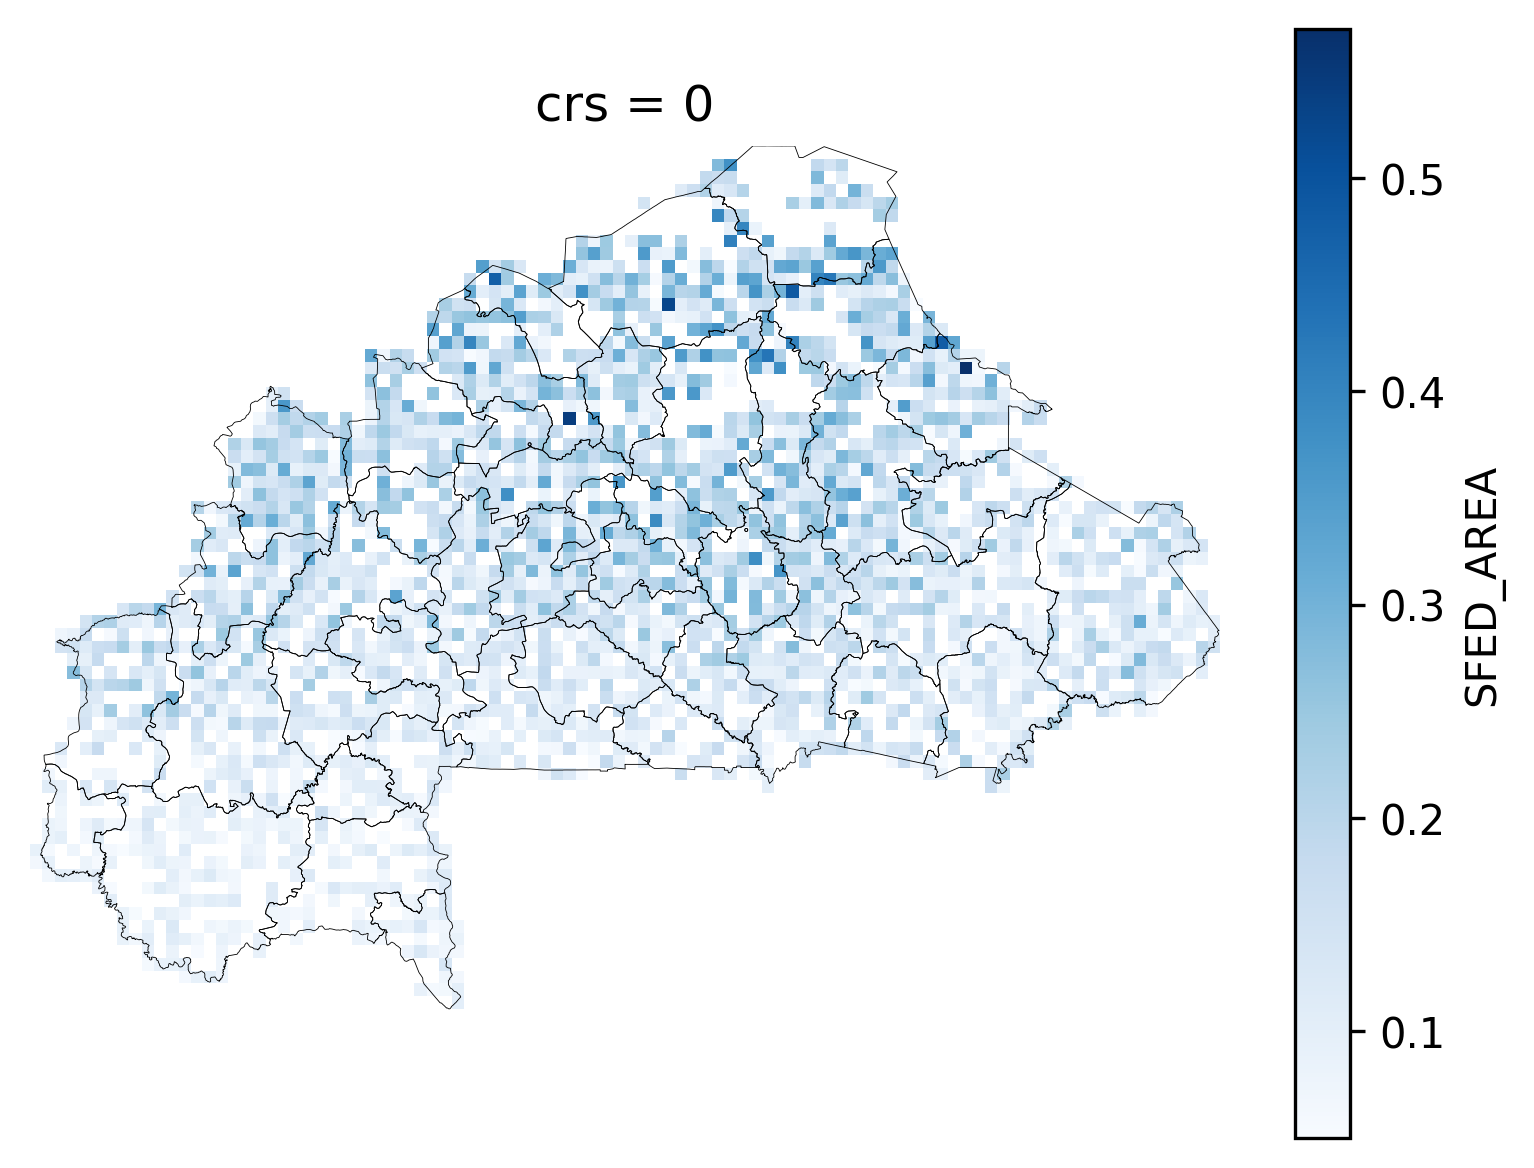

In [61]:
fig, ax = plt.subplots(dpi=300)
adm.boundary.plot(ax=ax, color="k", linewidth=0.2)
ax.axis("off")
da_mean.plot(ax=ax, cmap="Blues")

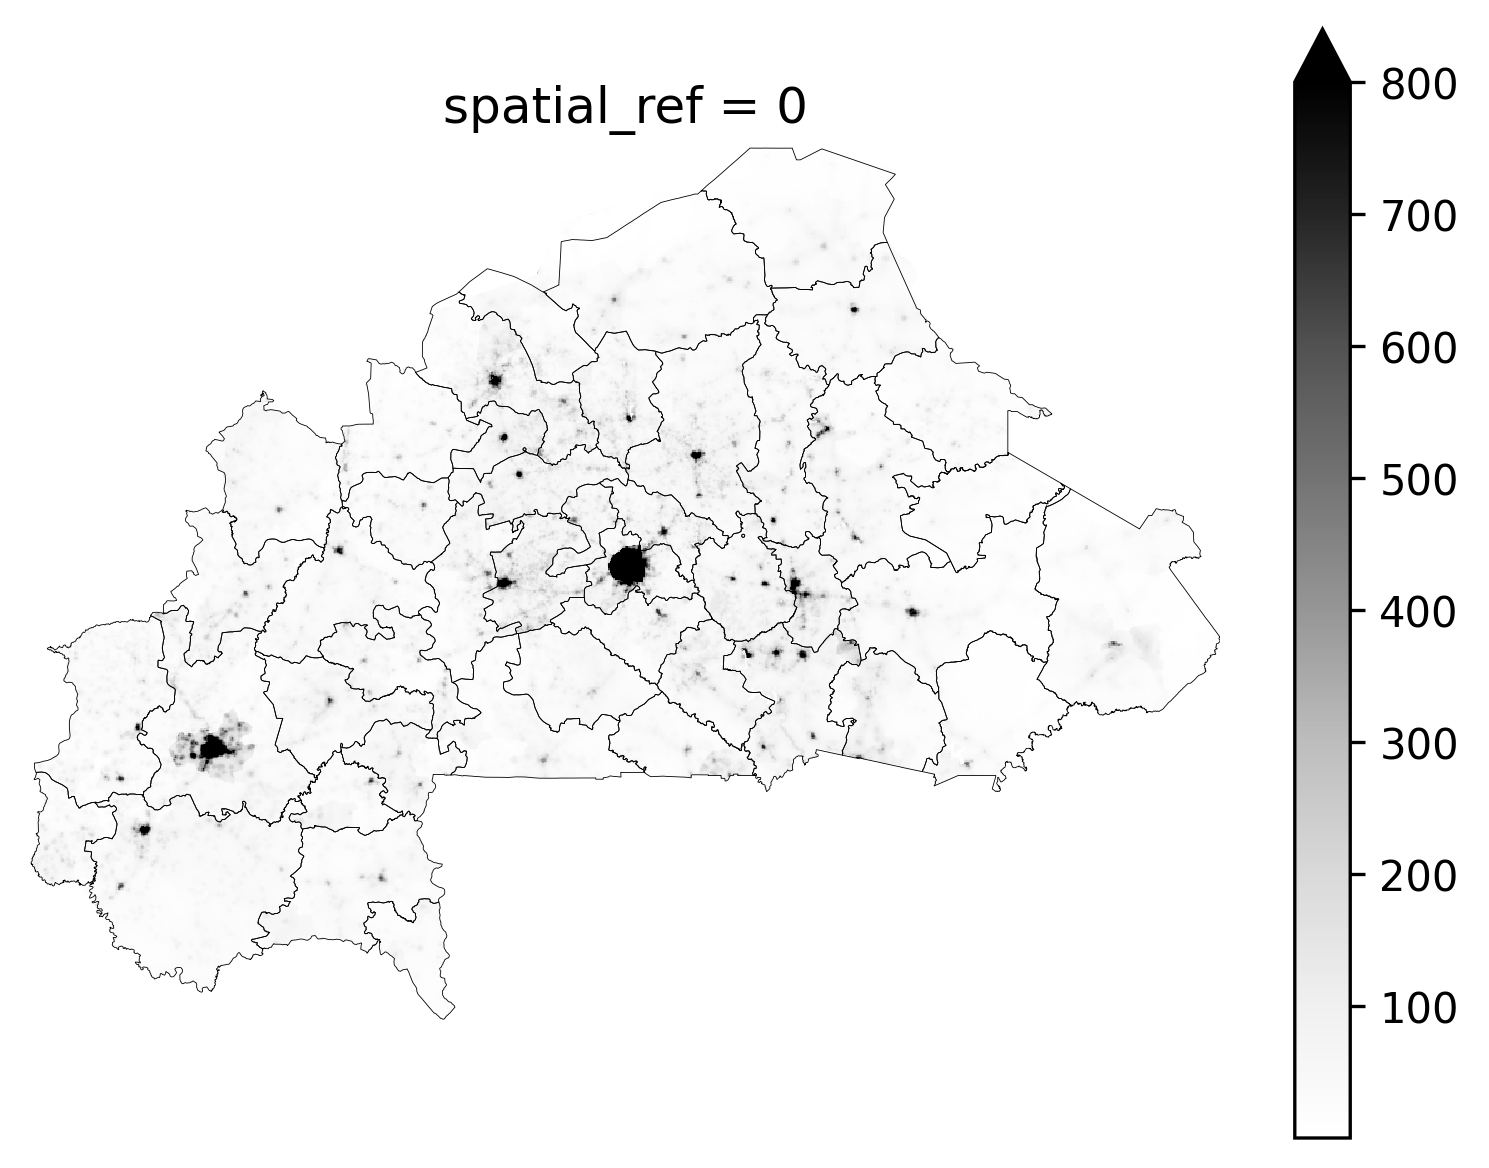

In [50]:
fig, ax = plt.subplots(dpi=300)
adm.boundary.plot(ax=ax, color="k", linewidth=0.2)
ax.axis("off")
pop.plot(ax=ax, cmap="Greys", vmax=800)

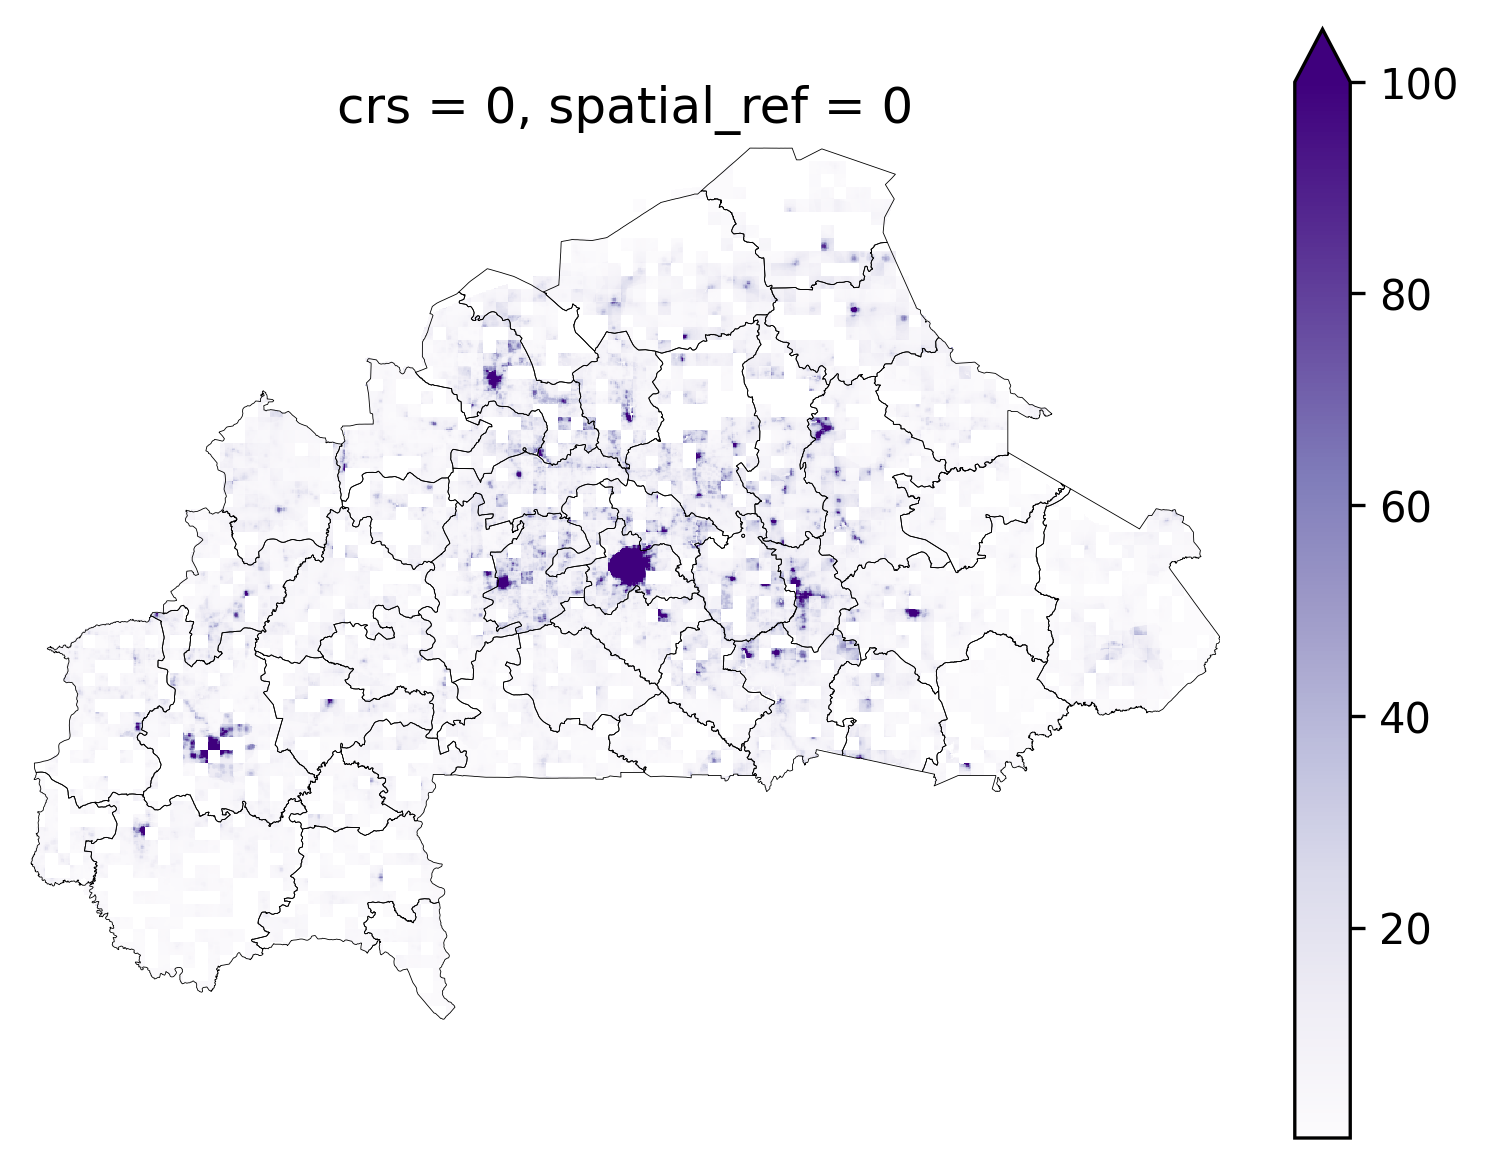

In [42]:
fig, ax = plt.subplots(dpi=300)
adm.boundary.plot(ax=ax, color="k", linewidth=0.2)
ax.axis("off")
exposure_mean.plot(ax=ax, cmap="Purples", vmax=100)